In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, Sequential


In [3]:
dataset_path = "URL dataset_features.csv"
df = pd.read_csv(dataset_path)


In [4]:
print("Dataset loaded successfully with shape:", df.shape)
print(df.head())


Dataset loaded successfully with shape: (450175, 16)
                         URL  url_length  num_dots  num_hyphens  num_slashes  \
0     https://www.google.com          22         2            0            2   
1    https://www.youtube.com          23         2            0            2   
2   https://www.facebook.com          24         2            0            2   
3      https://www.baidu.com          21         2            0            2   
4  https://www.wikipedia.org          25         2            0            2   

   num_digits  num_subdomains  contains_suspicious_words   entropy  \
0           0               2                          0  2.842371   
1           0               2                          0  3.189898   
2           0               2                          0  3.155639   
3           0               2                          0  3.180833   
4           0               2                          0  3.219528   

   contains_cyrillic  contains_hidden_chars  

In [5]:
# ==== CELL 2: Prepare features & split ====

label_col = 'phishing'

feature_cols = [c for c in df.columns if c not in ['URL', label_col]]

X = df[feature_cols].values.astype(float)
y = df[label_col].values.astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 🔥 IMPORTANT: SAME NAME JO PREDICTION ME LOAD HOGA
joblib.dump(scaler, "scaler_trained_on_real_v2.save")

print("Data prepared successfully")
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Data prepared successfully
Train shape: (288112, 14)
Validation shape: (72028, 14)
Test shape: (90035, 14)


Epoch 1/50
2251/2251 - 10s - 4ms/step - accuracy: 0.9861 - loss: 0.0629 - val_accuracy: 0.9900 - val_loss: 0.0416
Epoch 2/50
2251/2251 - 8s - 4ms/step - accuracy: 0.9902 - loss: 0.0401 - val_accuracy: 0.9907 - val_loss: 0.0398
Epoch 3/50
2251/2251 - 8s - 3ms/step - accuracy: 0.9905 - loss: 0.0389 - val_accuracy: 0.9907 - val_loss: 0.0391
Epoch 4/50
2251/2251 - 11s - 5ms/step - accuracy: 0.9905 - loss: 0.0383 - val_accuracy: 0.9907 - val_loss: 0.0383
Epoch 5/50
2251/2251 - 10s - 4ms/step - accuracy: 0.9906 - loss: 0.0377 - val_accuracy: 0.9907 - val_loss: 0.0378
Epoch 6/50
2251/2251 - 8s - 4ms/step - accuracy: 0.9906 - loss: 0.0373 - val_accuracy: 0.9907 - val_loss: 0.0375
Epoch 7/50
2251/2251 - 11s - 5ms/step - accuracy: 0.9907 - loss: 0.0368 - val_accuracy: 0.9905 - val_loss: 0.0372
Epoch 8/50
2251/2251 - 9s - 4ms/step - accuracy: 0.9907 - loss: 0.0366 - val_accuracy: 0.9910 - val_loss: 0.0367
Epoch 9/50
2251/2251 - 8s - 3ms/step - accuracy: 0.9907 - loss: 0.0362 - val_accuracy: 0.990

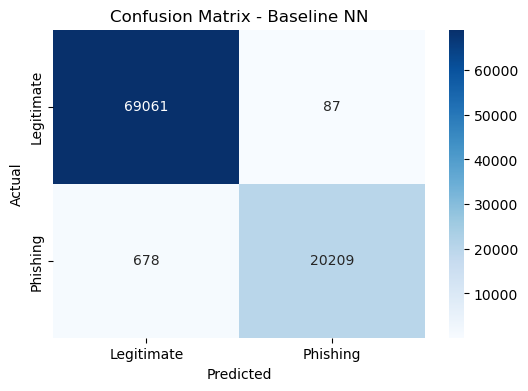


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     69148
    Phishing       1.00      0.97      0.98     20887

    accuracy                           0.99     90035
   macro avg       0.99      0.98      0.99     90035
weighted avg       0.99      0.99      0.99     90035



In [6]:
# ==== CELL 3A + 3B: Build, Train & Evaluate baseline SNN classifier ====

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# ---- Build baseline model ----
def build_snn(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(28, activation='relu')(inp)
    out = layers.Dense(2, activation='softmax')(x)
    model = models.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ---- Train model ----
snn = build_snn(X_train.shape[1])

history = snn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=2
)

# ---- SAVE MODEL (🔥 SAME NAME JO BACKEND ME LOAD HOGA) ----
snn.save("snn_trained_on_real_v2.keras")
print("✅ Model trained and saved as snn_trained_on_real_v2.keras")

# ---- Evaluate model ----
val_loss, val_acc = snn.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = snn.evaluate(X_test, y_test, verbose=0)

print(f"\n✅ Validation Accuracy: {val_acc*100:.2f}%")
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

# ---- Predictions ----
y_pred_probs = snn.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline NN")
plt.show()

# ---- Classification Report ----
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))


In [7]:
# ==== CELL 4: Prepare phishing-only data for GAN (FINAL CORRECT) ====

# Select only phishing samples from TRAINING DATA (already scaled & correct features)
phish_mask = (y_train == 1)
X_phish = X_train[phish_mask]

print("Phishing samples for GAN training:", X_phish.shape)

# GAN dimensions (must match model features)
latent_dim = 32
feat_dim = X_phish.shape[1]   # 🔥 MUST BE 14


Phishing samples for GAN training: (66840, 14)


In [8]:
# ==== CELL 5: GAN Training (FINAL CORRECT & SAFE VERSION) ====

import collections
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# ---------------- USER SETTINGS ----------------
latent_dim = 32
batch_size = 512
max_steps = 20000
critic_steps_base = 10
critic_steps_after = 5
warmup_steps = 2000
initial_g_updates = 2
lambda_gp = 10.0
fm_weight = 10.0
gen_save_name = "generator_phish_gan_robust.keras"

# ---------------- USE PHISHING DATA FROM PREVIOUS CELL ----------------
# 🔥 VERY IMPORTANT: USE X_phish DIRECTLY (NO CSV, NO URL, NO NEW SCALER)

n_phish = X_phish.shape[0]
feat_dim = X_phish.shape[1]     # MUST BE 14

print("Using phishing samples:", X_phish.shape)

# ---------------- TF DATA PIPELINE ----------------
dataset = (
    tf.data.Dataset.from_tensor_slices(X_phish.astype(np.float32))
    .shuffle(buffer_size=2000, reshuffle_each_iteration=True)
    .repeat()
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)
data_iter = iter(dataset)

# ---------------- MINIBATCH STDDEV LAYER ----------------
def minibatch_stddev_layer(x, group_size=4):
    group_size = tf.minimum(group_size, tf.shape(x)[0])
    y = tf.reshape(x, [group_size, -1, x.shape[1]])
    y = tf.math.reduce_std(y, axis=0, keepdims=True)
    y = tf.tile(y, [group_size, 1, 1])
    y = tf.reshape(y, [tf.shape(x)[0], 1])
    return tf.concat([x, y], axis=1)

# ---------------- GENERATOR ----------------
def build_generator():
    inp = layers.Input(shape=(latent_dim,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(512, activation="relu")(x)
    out = layers.Dense(feat_dim, activation="linear")(x)
    return models.Model(inp, out, name="Generator")

# ---------------- CRITIC ----------------
def build_critic():
    inp = layers.Input(shape=(feat_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(1)(x)
    return models.Model(inp, out, name="Critic")

G = build_generator()
C = build_critic()

g_optimizer = optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
c_optimizer = optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)

# ---------------- TRAINING STEPS ----------------
@tf.function
def train_critic_step(real_batch):
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake = G(noise, training=True)
        real_score = C(real_batch, training=True)
        fake_score = C(fake, training=True)
        loss = tf.reduce_mean(fake_score) - tf.reduce_mean(real_score)
    grads = tape.gradient(loss, C.trainable_variables)
    c_optimizer.apply_gradients(zip(grads, C.trainable_variables))
    return loss

@tf.function
def train_generator_step():
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake = G(noise, training=True)
        fake_score = C(fake, training=True)
        loss = -tf.reduce_mean(fake_score)
    grads = tape.gradient(loss, G.trainable_variables)
    g_optimizer.apply_gradients(zip(grads, G.trainable_variables))
    return loss

# ---------------- TRAIN LOOP ----------------
for step in range(1, max_steps + 1):

    critic_steps = critic_steps_base if step < warmup_steps else critic_steps_after

    for _ in range(critic_steps):
        real_batch = next(data_iter)
        c_loss = train_critic_step(real_batch)

    for _ in range(initial_g_updates):
        g_loss = train_generator_step()

    if step % 500 == 0:
        print(f"Step {step} | Critic Loss: {float(c_loss):.4f} | Gen Loss: {float(g_loss):.4f}")

# ---------------- SAVE GENERATOR ----------------
G.save(gen_save_name)
print("✅ Generator saved as", gen_save_name)


Using phishing samples: (66840, 14)
Step 500 | Critic Loss: -0.5340 | Gen Loss: -0.2304
Step 1000 | Critic Loss: -2.6219 | Gen Loss: -3.1153
Step 1500 | Critic Loss: -0.3007 | Gen Loss: -1.6282
Step 2000 | Critic Loss: -0.5824 | Gen Loss: -0.0379
Step 2500 | Critic Loss: -3.6771 | Gen Loss: 7.3757
Step 3000 | Critic Loss: -0.4458 | Gen Loss: 4.0160
Step 3500 | Critic Loss: -3.0641 | Gen Loss: 4.4628
Step 4000 | Critic Loss: -0.0207 | Gen Loss: 1.5324
Step 4500 | Critic Loss: -1.0009 | Gen Loss: 0.9628
Step 5000 | Critic Loss: 0.1158 | Gen Loss: 0.7144
Step 5500 | Critic Loss: 0.5819 | Gen Loss: -0.8320
Step 6000 | Critic Loss: -0.4322 | Gen Loss: -2.9465
Step 6500 | Critic Loss: -2.9245 | Gen Loss: 5.4594
Step 7000 | Critic Loss: -4.1978 | Gen Loss: -0.9190
Step 7500 | Critic Loss: 0.8314 | Gen Loss: 0.8919
Step 8000 | Critic Loss: -14.5663 | Gen Loss: 1.3161
Step 8500 | Critic Loss: -7.4547 | Gen Loss: -6.7658
Step 9000 | Critic Loss: -5.1831 | Gen Loss: 9.6990
Step 9500 | Critic Loss

✅ Using GAN file: GAN_generated_phishing_20000.csv


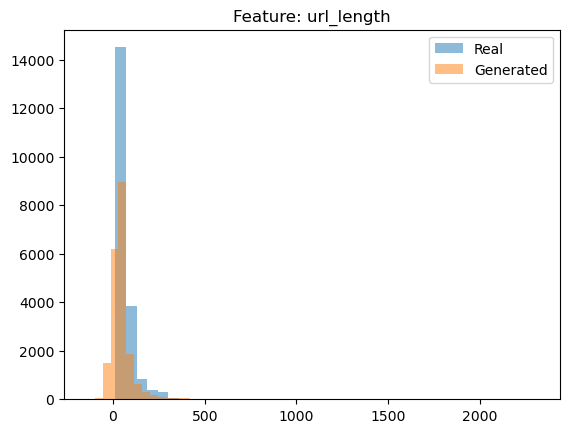

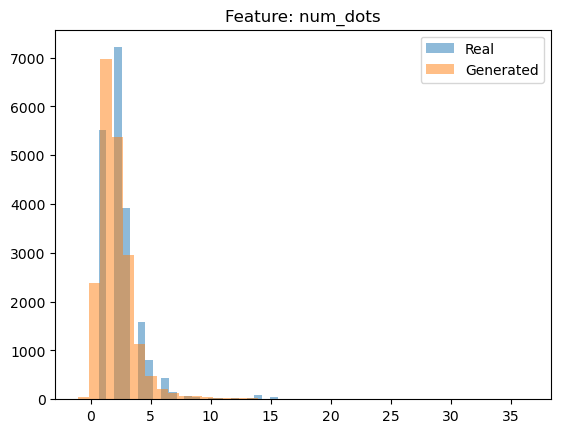

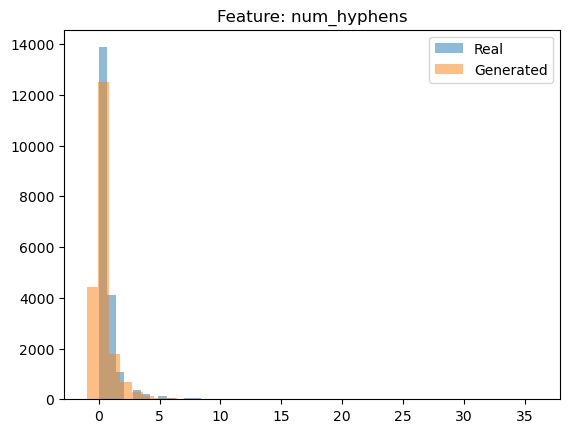

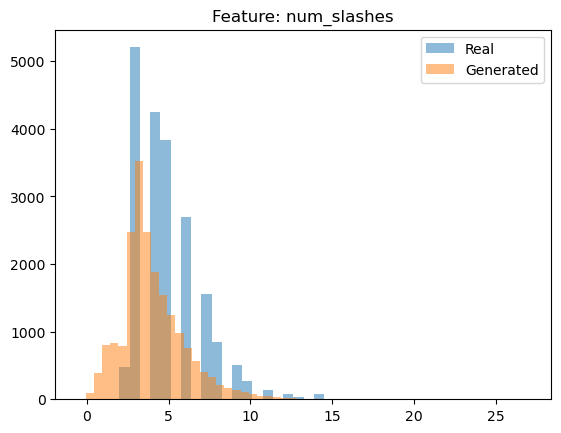

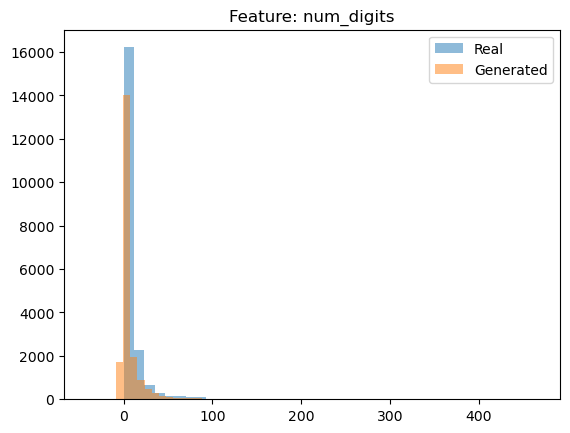

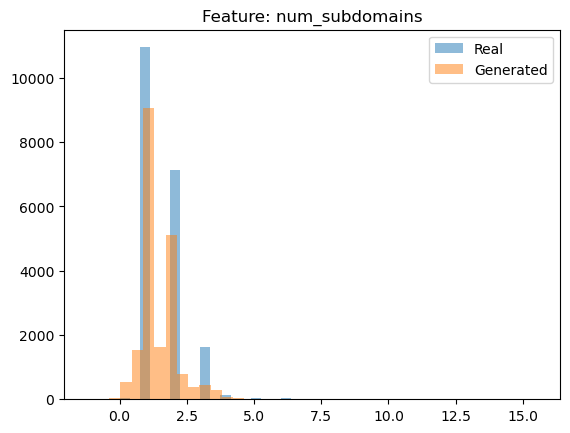

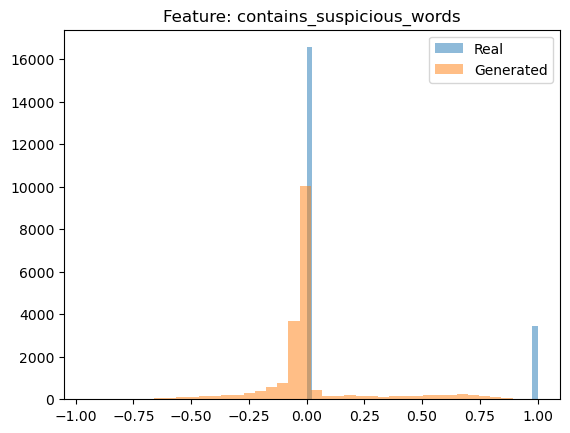

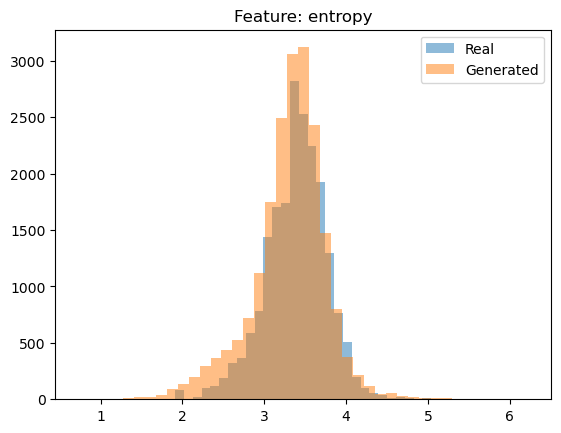

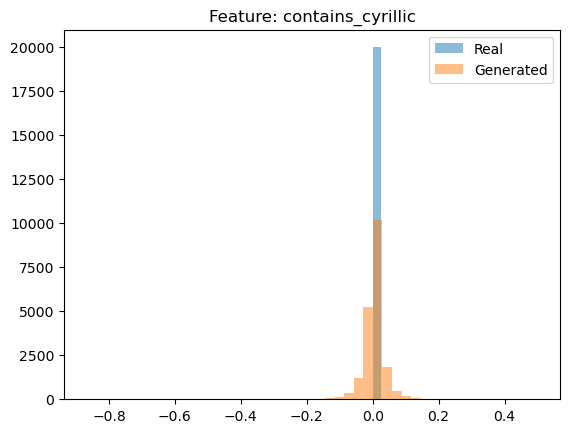

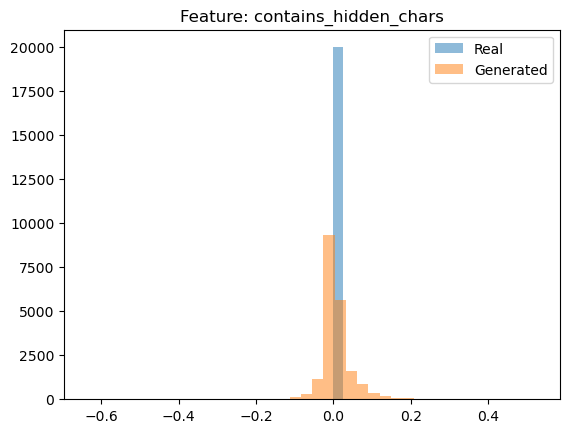

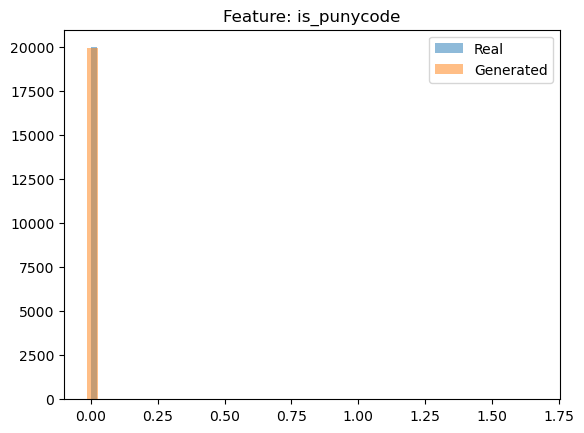

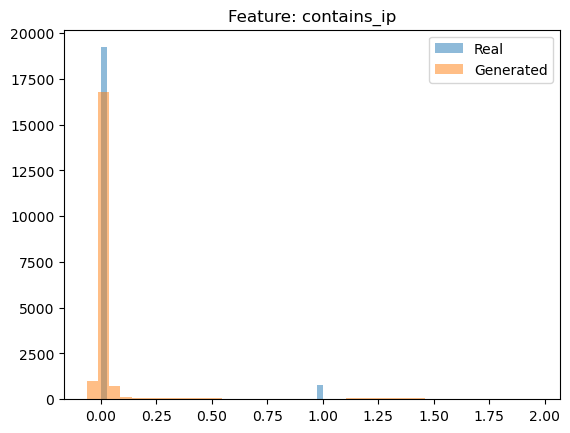

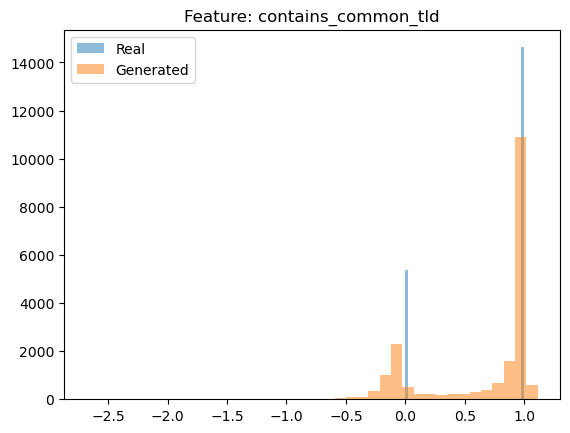

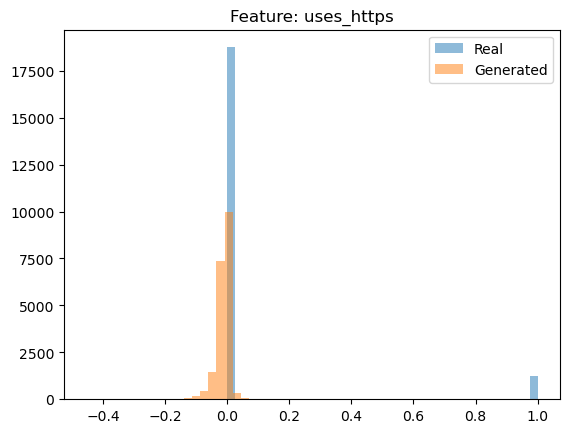

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 🔥 Find GAN csv automatically
gan_files = [f for f in os.listdir() if f.startswith("GAN_generated") and f.endswith(".csv")]

if len(gan_files) == 0:
    print("❌ No GAN generated CSV found. Skip this cell safely.")
else:
    gen_file = gan_files[0]
    print("✅ Using GAN file:", gen_file)

    gen = pd.read_csv(gen_file)

    real = pd.read_csv("URL dataset_features.csv")
    real = real[real["phishing"] == 1].drop(columns=["phishing", "URL"]).sample(len(gen))

    # Match feature order
    gen = gen[real.columns]

    # Compare feature distributions
    for col in real.columns:
        plt.figure()
        plt.hist(real[col], bins=40, alpha=0.5, label='Real')
        plt.hist(gen[col], bins=40, alpha=0.5, label='Generated')
        plt.legend()
        plt.title(f'Feature: {col}')
        plt.show()


In [11]:
# ==== CELL 6: Generate Synthetic Phishing Samples from GAN (FINAL SAFE) ====

import numpy as np
import pandas as pd
import gzip
import tensorflow as tf
from tensorflow.keras.models import load_model
import os

# ---------------- CONFIG ----------------
GEN_MODEL_PATH = "generator_phish_gan_robust.keras"   # 🔥 MUST MATCH SAVED NAME
OUT_GEN_CSV = "GAN_generated_phishing"
BATCH_GEN = 4096

# ---------------- CHECK REQUIRED OBJECTS ----------------
if 'scaler' not in globals():
    raise RuntimeError("❌ scaler not found. Run Prepare features & split cell first.")

if 'df' not in globals():
    raise RuntimeError("❌ df not found. Run dataset load cell first.")

# ---------------- LOAD GENERATOR ----------------
G = load_model(GEN_MODEL_PATH)
latent_dim = int(G.input_shape[1])
print("✅ Loaded generator:", GEN_MODEL_PATH, "| latent_dim =", latent_dim)

# ---------------- HOW MANY TO GENERATE (50% OF REAL PHISHING) ----------------
num_real_phish = df[df['phishing'] == 1].shape[0]
N_synth = max(int(0.5 * num_real_phish), 1)
print("Generating synthetic samples:", N_synth)

# ---------------- FEATURE COLUMNS (🔥 EXACT SAME 14 FEATURES) ----------------
drop_cols = ['phishing', 'URL']
feature_cols = [c for c in df.columns if c not in drop_cols]
print("Feature columns:", feature_cols)

# ---------------- GENERATE & SAVE (GZIP CSV) ----------------
out_path = f"{OUT_GEN_CSV}_{N_synth}.csv.gz"
first_chunk = True
generated = 0

with gzip.open(out_path, "wt") as fout:
    while generated < N_synth:
        bs = min(BATCH_GEN, N_synth - generated)
        noise = np.random.normal(size=(bs, latent_dim)).astype(np.float32)

        gen_scaled = G.predict(noise, batch_size=bs, verbose=0)
        gen_unscaled = scaler.inverse_transform(gen_scaled)

        df_chunk = pd.DataFrame(gen_unscaled, columns=feature_cols)
        df_chunk["phishing"] = 1

        df_chunk.to_csv(fout, index=False, header=first_chunk, mode="a")
        first_chunk = False
        generated += bs

        print(f"Generated {generated}/{N_synth}", end="\r")

print(f"\n✅ Synthetic phishing samples saved to: {out_path}")


✅ Loaded generator: generator_phish_gan_robust.keras | latent_dim = 32
Generating synthetic samples: 52218
Feature columns: ['url_length', 'num_dots', 'num_hyphens', 'num_slashes', 'num_digits', 'num_subdomains', 'contains_suspicious_words', 'entropy', 'contains_cyrillic', 'contains_hidden_chars', 'is_punycode', 'contains_ip', 'contains_common_tld', 'uses_https']
Generated 52218/52218
✅ Synthetic phishing samples saved to: GAN_generated_phishing_52218.csv.gz


In [12]:
import pandas as pd

gen_path = "GAN_generated_phishing_52218.csv.gz"

gen = pd.read_csv(gen_path, compression="gzip")

# 🔥 REMOVE LABEL COLUMN
if "phishing" in gen.columns:
    gen = gen.drop(columns=["phishing"])

print("After fix shape:", gen.shape)   # MUST BE (52218, 14)

# Save cleaned version
gen.to_csv("GAN_generated_phishing_52218_clean.csv", index=False)

print("✅ Clean GAN file saved as GAN_generated_phishing_52218_clean.csv")


After fix shape: (52218, 14)
✅ Clean GAN file saved as GAN_generated_phishing_52218_clean.csv


In [1]:
# ==== FINAL UNIFIED URL PREDICTOR (BACKEND READY – PERFECT VERSION) ====

import re, math
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from urllib.parse import urlparse

# ---------------- CONFIG ----------------
THRESH = 0.70

TRUSTED_DOMAINS = {
    "google.com", "github.com", "microsoft.com", "amazon.com",
    "facebook.com", "apple.com", "linkedin.com", "youtube.com",
    "wikipedia.org", "stackoverflow.com"
}

SCALER_PATH = "scaler_trained_on_real_v2.save"
MODEL_PATH  = "snn_trained_on_real_v2.keras"

# ---------------- LOAD SCALER + MODEL ----------------
scaler = joblib.load(SCALER_PATH)
snn = tf.keras.models.load_model(MODEL_PATH)

print("✅ Loaded scaler + model successfully")
print("🔥 URL PHISHING DETECTOR READY")

# ---------------- FEATURE HELPERS ----------------
def shannon_entropy(s):
    if not s:
        return 0.0
    probs = [float(s.count(c)) / len(s) for c in set(s)]
    return -sum(p * math.log(p + 1e-12, 2) for p in probs)

cyrillic_re = re.compile(r'[\u0400-\u04FF]')
invisible_chars = ['\u200b', '\u200c', '\u200d', '\ufeff']
suspicious_tokens = [
    "login","secure","account","update","verify","signin","bank",
    "confirm","paypal","reset","auth","security","verification"
]
common_tlds = ['.com','.net','.org','.info','.biz','.co','.uk','.ru','.io','.gov']

# ---------------- FEATURE EXTRACTION (🔥 EXACT 14 FEATURES ORDER) ----------------
def extract_features_from_url(url):

    if not re.match(r'^[a-zA-Z][a-zA-Z0-9+.-]*://', url):
        url = "http://" + url

    parsed = urlparse(url)
    host = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""

    full = (host + path + ("?" + query if query else "")).strip()

    url_length = len(url)
    num_dots = url.count('.')
    num_hyphens = url.count('-')
    num_slashes = url.count('/')
    num_digits = sum(c.isdigit() for c in url)

    if host:
        parts = host.split('.')
        num_subdomains = max(0, len(parts) - 2)
    else:
        num_subdomains = 0

    contains_suspicious_words = int(any(tok in url.lower() for tok in suspicious_tokens))
    entropy = shannon_entropy(full)
    contains_cyrillic = int(bool(cyrillic_re.search(url)))
    contains_hidden_chars = int(any(ch in url for ch in invisible_chars))
    is_punycode = int(host.startswith("xn--")) if host else 0
    contains_ip = int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', host)))
    contains_common_tld = int(any(host.endswith(tld) for tld in common_tlds))
    uses_https = int(parsed.scheme == "https")

    feat_vector = [
        url_length,
        num_dots,
        num_hyphens,
        num_slashes,
        num_digits,
        num_subdomains,
        contains_suspicious_words,
        entropy,
        contains_cyrillic,
        contains_hidden_chars,
        is_punycode,
        contains_ip,
        contains_common_tld,
        uses_https
    ]

    return np.array(feat_vector, dtype=float), host

# ---------------- TRUSTED DOMAIN CHECK ----------------
def is_trusted_domain(host):
    host = host.lower()
    for td in TRUSTED_DOMAINS:
        if host == td or host.endswith("." + td):
            return True
    return False

# ---------------- MAIN PREDICTION FUNCTION (🔥 BACKEND CORE) ----------------
def predict_url(url):

    feats, host = extract_features_from_url(url)

    # Whitelist check
    if is_trusted_domain(host):
        return {
            "url": url,
            "result": "Legitimate",
            "confidence": 1.0,
            "reason": "Trusted whitelist domain"
        }

    # Scale features
    feats_scaled = scaler.transform(feats.reshape(1, -1))

    # Predict (SOFTMAX MODEL)
    pred = snn.predict(feats_scaled, verbose=0)

    # pred[0][0] = Legitimate prob
    # pred[0][1] = Phishing prob
    prob = float(pred[0][1])   # 🔥 TAKE PHISHING PROBABILITY

    label = "Phishing" if prob >= THRESH else "Legitimate"

    return {
        "url": url,
        "result": label,
        "confidence": round(prob, 4)
    }

# ---------------- TEST LOOP (CLI MODE) ----------------
while True:
    url = input("\nEnter URL (or type 'exit'): ").strip()
    if url.lower() in ("exit", "quit"):
        break
    try:
        out = predict_url(url)
        print("Prediction:", out)
    except Exception as e:
        print("❌ Error:", e)


✅ Loaded scaler + model successfully
🔥 URL PHISHING DETECTOR READY



Enter URL (or type 'exit'):  https://www.patria.org.ve


Prediction: {'url': 'https://www.patria.org.ve', 'result': 'Legitimate', 'confidence': 0.0256}



Enter URL (or type 'exit'):  https://www.udemy.com


Prediction: {'url': 'https://www.udemy.com', 'result': 'Legitimate', 'confidence': 0.5819}


...


Enter URL (or type 'exit'):  https://www.amazon.com/Woman-Sin-Fishtank-Ensemble/dp/B003MC528S


Prediction: {'url': 'https://www.amazon.com/Woman-Sin-Fishtank-Ensemble/dp/B003MC528S', 'result': 'Legitimate', 'confidence': 1.0, 'reason': 'Trusted whitelist domain'}



Enter URL (or type 'exit'):  https://www.amazon.com/Until-Theres-Nothing-Left-Us/dp/B000G8NXHS


Prediction: {'url': 'https://www.amazon.com/Until-Theres-Nothing-Left-Us/dp/B000G8NXHS', 'result': 'Legitimate', 'confidence': 1.0, 'reason': 'Trusted whitelist domain'}



Enter URL (or type 'exit'):  exit


In [10]:
# ==== JUPYTER FRIENDLY URL PHISHING DETECTOR (SINGLE + FILE UPLOAD) ====

import re, math, os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from urllib.parse import urlparse

# For file chooser (Jupyter safe)
import tkinter as tk
from tkinter import filedialog

# ---------------- CONFIG ----------------
THRESH = 0.70

TRUSTED_DOMAINS = {
    "google.com", "github.com", "microsoft.com", "amazon.com",
    "facebook.com", "apple.com", "linkedin.com", "youtube.com",
    "wikipedia.org", "stackoverflow.com"
}

SCALER_PATH = "scaler_trained_on_real_v2.save"
MODEL_PATH  = "snn_trained_on_real_v2.keras"

# ---------------- LOAD SCALER + MODEL ----------------
scaler = joblib.load(SCALER_PATH)
snn = tf.keras.models.load_model(MODEL_PATH)

print("✅ Loaded scaler + model successfully")
print("🔥 URL PHISHING DETECTOR READY")

# ---------------- FEATURE HELPERS ----------------
def shannon_entropy(s):
    if not s:
        return 0.0
    probs = [float(s.count(c)) / len(s) for c in set(s)]
    return -sum(p * math.log(p + 1e-12, 2) for p in probs)

cyrillic_re = re.compile(r'[\u0400-\u04FF]')
invisible_chars = ['\u200b', '\u200c', '\u200d', '\ufeff']
suspicious_tokens = [
    "login","secure","account","update","verify","signin","bank",
    "confirm","paypal","reset","auth","security","verification"
]
common_tlds = ['.com','.net','.org','.info','.biz','.co','.uk','.ru','.io','.gov']

# ---------------- FEATURE EXTRACTION ----------------
def extract_features_from_url(url):

    if not re.match(r'^[a-zA-Z][a-zA-Z0-9+.-]*://', url):
        url = "http://" + url

    parsed = urlparse(url)
    host = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""

    full = (host + path + ("?" + query if query else "")).strip()

    url_length = len(url)
    num_dots = url.count('.')
    num_hyphens = url.count('-')
    num_slashes = url.count('/')
    num_digits = sum(c.isdigit() for c in url)

    if host:
        parts = host.split('.')
        num_subdomains = max(0, len(parts) - 2)
    else:
        num_subdomains = 0

    contains_suspicious_words = int(any(tok in url.lower() for tok in suspicious_tokens))
    entropy = shannon_entropy(full)
    contains_cyrillic = int(bool(cyrillic_re.search(url)))
    contains_hidden_chars = int(any(ch in url for ch in invisible_chars))
    is_punycode = int(host.startswith("xn--")) if host else 0
    contains_ip = int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', host)))
    contains_common_tld = int(any(host.endswith(tld) for tld in common_tlds))
    uses_https = int(parsed.scheme == "https")

    feat_vector = [
        url_length,
        num_dots,
        num_hyphens,
        num_slashes,
        num_digits,
        num_subdomains,
        contains_suspicious_words,
        entropy,
        contains_cyrillic,
        contains_hidden_chars,
        is_punycode,
        contains_ip,
        contains_common_tld,
        uses_https
    ]

    return np.array(feat_vector, dtype=float), host

# ---------------- TRUSTED DOMAIN CHECK ----------------
def is_trusted_domain(host):
    host = host.lower()
    for td in TRUSTED_DOMAINS:
        if host == td or host.endswith("." + td):
            return True
    return False

# ---------------- SINGLE URL PREDICTION ----------------
def predict_url(url):

    feats, host = extract_features_from_url(url)

    if is_trusted_domain(host):
        return url, "Legitimate", 1.0

    feats_scaled = scaler.transform(feats.reshape(1, -1))
    pred = snn.predict(feats_scaled, verbose=0)

    prob = float(pred[0][1])
    label = "Phishing" if prob >= THRESH else "Legitimate"

    return url, label, round(prob, 4)

# ---------------- BULK FILE CHECK ----------------
def check_file_urls():

    print("\n📂 Opening file chooser...")

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    root.update()

    file_path = filedialog.askopenfilename(
        title="Select TXT file with URLs",
        filetypes=[("Text Files", "*.txt")]
    )

    root.destroy()

    if not file_path:
        print("❌ No file selected.")
        return

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        urls = [line.strip() for line in f.readlines() if line.strip()]

    print(f"\n🔎 Checking {len(urls)} URLs...\n")

    results = []
    phishing_count = 0
    legit_count = 0

    for url in urls:
        try:
            u, label, prob = predict_url(url)
            results.append([u, label, prob])

            if label == "Phishing":
                phishing_count += 1
            else:
                legit_count += 1

            print(f"{u}  -->  {label} ({prob})")

        except Exception as e:
            print(f"{url}  -->  ERROR: {e}")

    df = pd.DataFrame(results, columns=["URL", "Prediction", "Confidence"])
    df.to_csv("file_url_predictions.csv", index=False)

    print("\n================ FINAL SUMMARY ================")
    print("Total URLs checked:", len(urls))
    print("Phishing URLs     :", phishing_count)
    print("Legitimate URLs   :", legit_count)
    print("==============================================")
    print("📁 Results saved as: file_url_predictions.csv")

# ---------------- MENU ----------------

print("\nChoose option:")
print("1  Check single URL")
print("2  Upload TXT file with URLs")
print("3  Exit")

choice = input("Enter choice (1/2/3): ").strip()

if choice == "1":
    url = input("\nEnter URL: ").strip()
    u, label, prob = predict_url(url)
    print(f"\nResult: {label}")
    print(f"Confidence: {prob}")

elif choice == "2":
    check_file_urls()

elif choice == "3":
    print("\n👋 Exiting...")

else:
    print("❌ Invalid choice")


✅ Loaded scaler + model successfully
🔥 URL PHISHING DETECTOR READY

Choose option:
1  Check single URL
2  Upload TXT file with URLs
3  Exit


Enter choice (1/2/3):  1

Enter URL:  https://www.github.com/



Result: Legitimate
Confidence: 1.0
